### Task (1)

##### Data Loading & Understanding:

● Load the dataset using pandas.

● Display first few rows, dataset shape, and column details.

● Identify the target variable (Purchase / Not Purchase).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('customer_purchase_prediction_dataset_1.csv')

In [3]:
data.head()

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Previous_Purchases,Engagement_Score,Purchase
0,1,62,Other,45.15,59,22,55,0
1,2,65,Male,79.51,90,77,35,1
2,3,18,Male,29.19,6,71,30,0
3,4,21,Other,79.63,91,33,45,1
4,5,21,Other,77.66,54,43,25,0


In [4]:
data.drop('Purchase', axis=1, inplace=True)

In [5]:
data.head()

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Previous_Purchases,Engagement_Score
0,1,62,Other,45.15,59,22,55
1,2,65,Male,79.51,90,77,35
2,3,18,Male,29.19,6,71,30
3,4,21,Other,79.63,91,33,45
4,5,21,Other,77.66,54,43,25


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1000 non-null   int64  
 1   Age                 1000 non-null   int64  
 2   Gender              1000 non-null   str    
 3   Annual_Income       1000 non-null   float64
 4   Spending_Score      1000 non-null   int64  
 5   Previous_Purchases  1000 non-null   int64  
 6   Engagement_Score    1000 non-null   int64  
dtypes: float64(1), int64(5), str(1)
memory usage: 54.8 KB


In [7]:
data.describe()

,Customer_ID,Age,Annual_Income,Spending_Score,Previous_Purchases,Engagement_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.267000,111.962960,50.768000,49.456000,32.210000
std,288.819436,15.242311,52.844111,28.660454,28.543595,15.641629
min,1.000000,18.000000,20.010000,1.000000,1.000000,5.000000
25%,250.750000,30.000000,67.800000,27.000000,25.000000,20.000000
50%,500.500000,43.000000,114.140000,50.000000,49.000000,30.000000
75%,750.250000,56.000000,158.452500,76.000000,74.000000,45.000000
max,1000.000000,69.000000,199.730000,100.000000,99.000000,65.000000


In [8]:
data.shape

(1000, 7)

In [9]:
data.isnull().sum()

Customer_ID           0
Age                   0
Gender                0
Annual_Income         0
Spending_Score        0
Previous_Purchases    0
Engagement_Score      0
dtype: int64

#### identify the Target value

In [10]:
data['Purchase'] = (
    (data['Spending_Score'] > 40) &
    (data['Engagement_Score'] > 20) &
    (data['Previous_Purchases'] >= 20)
).astype(int)

In [11]:
data

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Previous_Purchases,Engagement_Score,Purchase
0,1,62,Other,45.15,59,22,55,1
1,2,65,Male,79.51,90,77,35,1
2,3,18,Male,29.19,6,71,30,0
3,4,21,Other,79.63,91,33,45,1
4,5,21,Other,77.66,54,43,25,1
...,...,...,...,...,...,...,...,...
995,996,54,Male,143.72,11,29,30,0
996,997,19,Male,164.19,37,90,40,0
997,998,47,Female,113.31,7,69,25,0
998,999,23,Male,72.98,39,31,45,0


In [12]:
data['Purchase'].value_counts()

Purchase
0    638
1    362
Name: count, dtype: int64

### Task (2)

#### Data preprocessing

● Handle missing values (imputation or removal).

● Encode categorical variables (Label Encoding / One-Hot Encoding).

● Scale numerical features using StandardScaler or MinMaxScaler.

● Split data into training and testing sets.

In [13]:
# Handle Missing Values
data.isnull().sum()

Customer_ID           0
Age                   0
Gender                0
Annual_Income         0
Spending_Score        0
Previous_Purchases    0
Engagement_Score      0
Purchase              0
dtype: int64

In [14]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()
encoded_data=encoder.fit_transform(data[['Gender']]).toarray()


In [15]:
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out())
encoded_df

,Gender_Female,Gender_Male,Gender_Other
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
995,0.0,1.0,0.0
996,0.0,1.0,0.0
997,1.0,0.0,0.0
998,0.0,1.0,0.0


Reordering the target output purchase

In [16]:
data = pd.concat(
    [data.drop('Gender', axis=1), encoded_df],
    axis=1
)

In [17]:
data.head()

,Customer_ID,Age,Annual_Income,Spending_Score,Previous_Purchases,Engagement_Score,Purchase,Gender_Female,Gender_Male,Gender_Other
0,1,62,45.15,59,22,55,1,0.0,0.0,1.0
1,2,65,79.51,90,77,35,1,0.0,1.0,0.0
2,3,18,29.19,6,71,30,0,0.0,1.0,0.0
3,4,21,79.63,91,33,45,1,0.0,0.0,1.0
4,5,21,77.66,54,43,25,1,0.0,0.0,1.0


In [18]:
purchase_col = data.pop('Purchase')
data['Purchase'] = purchase_col

In [19]:
data.head()

,Customer_ID,Age,Annual_Income,Spending_Score,Previous_Purchases,Engagement_Score,Gender_Female,Gender_Male,Gender_Other,Purchase
0,1,62,45.15,59,22,55,0.0,0.0,1.0,1
1,2,65,79.51,90,77,35,0.0,1.0,0.0,1
2,3,18,29.19,6,71,30,0.0,1.0,0.0,0
3,4,21,79.63,91,33,45,0.0,0.0,1.0,1
4,5,21,77.66,54,43,25,0.0,0.0,1.0,1


In [20]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1000 non-null   int64  
 1   Age                 1000 non-null   int64  
 2   Annual_Income       1000 non-null   float64
 3   Spending_Score      1000 non-null   int64  
 4   Previous_Purchases  1000 non-null   int64  
 5   Engagement_Score    1000 non-null   int64  
 6   Gender_Female       1000 non-null   float64
 7   Gender_Male         1000 non-null   float64
 8   Gender_Other        1000 non-null   float64
 9   Purchase            1000 non-null   int64  
dtypes: float64(4), int64(6)
memory usage: 78.3 KB


#### Scaling the data

In [21]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()


In [22]:
num_cols = [
    'Age',
    'Annual_Income',
    'Spending_Score',
    'Previous_Purchases',
    'Engagement_Score'
]
# data[num_cols].isnull().sum() # to check any NaNs not present there.
scaled_data=scale.fit_transform(data[num_cols])
scaled_data

array([[ 1.22962809, -1.26497333,  0.28736876, -0.96237837,  1.45773841],
       [ 1.42654712, -0.61443362,  1.36953976,  0.96546292,  0.17845942],
       [-1.65851775, -1.56714486, -1.56279456,  0.75515296, -0.14136033],
       ...,
       [ 0.24503292,  0.02550358, -1.52788581,  0.68504964, -0.46118008],
       [-1.33031936, -0.73806646, -0.41080607, -0.64691344,  0.81809892],
       [-0.6082829 ,  0.43351088, -0.37589733, -0.05103522, -0.46118008]],
      shape=(1000, 5))

In [23]:
print(f"scaled data mean {scaled_data.mean()} and scaled data standard deviation {scaled_data.std()}")

scaled data mean -5.613287612504792e-17 and scaled data standard deviation 1.0


In [24]:
data.head()

,Customer_ID,Age,Annual_Income,Spending_Score,Previous_Purchases,Engagement_Score,Gender_Female,Gender_Male,Gender_Other,Purchase
0,1,62,45.15,59,22,55,0.0,0.0,1.0,1
1,2,65,79.51,90,77,35,0.0,1.0,0.0,1
2,3,18,29.19,6,71,30,0.0,1.0,0.0,0
3,4,21,79.63,91,33,45,0.0,0.0,1.0,1
4,5,21,77.66,54,43,25,0.0,0.0,1.0,1


Replace the original data to the scaled data

In [25]:
data[num_cols] = scale.fit_transform(data[num_cols])

In [26]:
print(data.head())

   Customer_ID       Age  Annual_Income  Spending_Score  Previous_Purchases  \
0            1  1.229628      -1.264973        0.287369           -0.962378   
1            2  1.426547      -0.614434        1.369540            0.965463   
2            3 -1.658518      -1.567145       -1.562795            0.755153   
3            4 -1.461599      -0.612162        1.404449           -0.576810   
4            5 -1.461599      -0.649460        0.112825           -0.226294   

   Engagement_Score  Gender_Female  Gender_Male  Gender_Other  Purchase  
0          1.457738            0.0          0.0           1.0         1  
1          0.178459            0.0          1.0           0.0         1  
2         -0.141360            0.0          1.0           0.0         0  
3          0.818099            0.0          0.0           1.0         1  
4         -0.461180            0.0          0.0           1.0         1  


#### Data split for train and test.

In [27]:
ready_data_tt=data.drop('Customer_ID',axis=1)

In [28]:
ready_data_tt.head()

,Age,Annual_Income,Spending_Score,Previous_Purchases,Engagement_Score,Gender_Female,Gender_Male,Gender_Other,Purchase
0,1.229628,-1.264973,0.287369,-0.962378,1.457738,0.0,0.0,1.0,1
1,1.426547,-0.614434,1.369540,0.965463,0.178459,0.0,1.0,0.0,1
2,-1.658518,-1.567145,-1.562795,0.755153,-0.141360,0.0,1.0,0.0,0
3,-1.461599,-0.612162,1.404449,-0.576810,0.818099,0.0,0.0,1.0,1
4,-1.461599,-0.649460,0.112825,-0.226294,-0.461180,0.0,0.0,1.0,1


In [29]:
X = data.drop('Purchase', axis=1) # input featues/ independent variable
y = data['Purchase']              # dependent variable/ target value

In [30]:
X

,Customer_ID,Age,Annual_Income,Spending_Score,Previous_Purchases,Engagement_Score,Gender_Female,Gender_Male,Gender_Other
0,1,1.229628,-1.264973,0.287369,-0.962378,1.457738,0.0,0.0,1.0
1,2,1.426547,-0.614434,1.369540,0.965463,0.178459,0.0,1.0,0.0
2,3,-1.658518,-1.567145,-1.562795,0.755153,-0.141360,0.0,1.0,0.0
3,4,-1.461599,-0.612162,1.404449,-0.576810,0.818099,0.0,0.0,1.0
4,5,-1.461599,-0.649460,0.112825,-0.226294,-0.461180,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
995,996,0.704511,0.601258,-1.388251,-0.717017,-0.141360,0.0,1.0,0.0
996,997,-1.592878,0.988817,-0.480624,1.421134,0.498279,0.0,1.0,0.0
997,998,0.245033,0.025504,-1.527886,0.685050,-0.461180,1.0,0.0,0.0
998,999,-1.330319,-0.738066,-0.410806,-0.646913,0.818099,0.0,1.0,0.0


In [31]:
y


0      1
1      1
2      0
3      1
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: Purchase, Length: 1000, dtype: int64

In [32]:
# splitig the data 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [33]:
X_train

,Customer_ID,Age,Annual_Income,Spending_Score,Previous_Purchases,Engagement_Score,Gender_Female,Gender_Male,Gender_Other
80,81,-1.658518,1.519889,1.718627,-1.172688,1.137919,0.0,0.0,1.0
684,685,1.295268,1.467256,-0.515532,-0.997430,-1.740459,1.0,0.0,0.0
621,622,-1.199040,0.361755,-0.480624,1.421134,-0.461180,0.0,1.0,0.0
807,808,-0.870842,1.490543,1.648810,-1.347947,-0.141360,1.0,0.0,0.0
148,149,-1.002121,-0.059695,-0.515532,-1.418050,0.818099,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
453,454,1.229628,-1.466989,0.531730,-1.523205,0.818099,0.0,1.0,0.0
165,166,0.310673,-0.093585,-0.410806,0.895360,1.777558,0.0,0.0,1.0
872,873,1.623466,-0.895021,0.392095,-1.102585,-1.100820,0.0,1.0,0.0
413,414,1.295268,0.741552,-1.492977,-0.191242,-0.461180,0.0,1.0,0.0


In [34]:
X_test

,Customer_ID,Age,Annual_Income,Spending_Score,Previous_Purchases,Engagement_Score,Gender_Female,Gender_Male,Gender_Other
883,884,-1.592878,0.514166,0.182643,0.930411,0.178459,0.0,1.0,0.0
731,732,-1.461599,0.733789,1.578992,0.579895,-1.100820,1.0,0.0,0.0
19,20,-0.148805,1.455138,0.252460,1.351031,0.818099,0.0,0.0,1.0
253,254,1.360907,-0.681457,-1.318433,-0.121139,-1.100820,0.0,0.0,1.0
687,688,-0.805202,-1.299431,-0.829711,-0.156190,0.498279,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
712,713,-1.199040,0.453201,1.090270,-1.453102,0.178459,1.0,0.0,0.0
838,839,-1.461599,1.354225,0.217551,0.965463,0.818099,1.0,0.0,0.0
325,326,-0.214445,-0.318889,1.020452,-0.927327,0.498279,0.0,1.0,0.0
879,880,1.689106,1.131573,0.322278,1.351031,-0.461180,1.0,0.0,0.0


In [35]:
y_train

80     0
684    0
621    0
807    0
148    0
      ..
453    0
165    0
872    0
413    0
223    0
Name: Purchase, Length: 750, dtype: int64

In [36]:
y_test

883    1
731    0
19     1
253    0
687    0
      ..
712    0
838    1
325    1
879    1
888    0
Name: Purchase, Length: 250, dtype: int64

### Task (3)


EDA- explotory data analysis

-> I just want to show how the some significant column represent their      destribution. explore by the histogram 

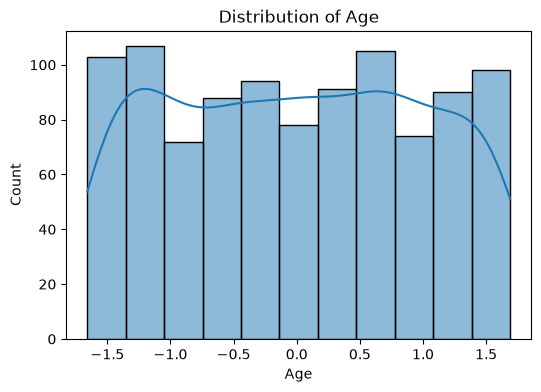

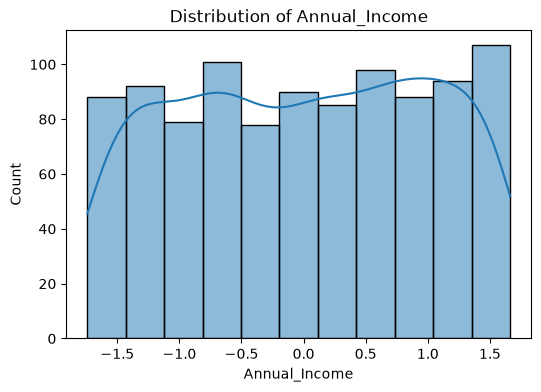

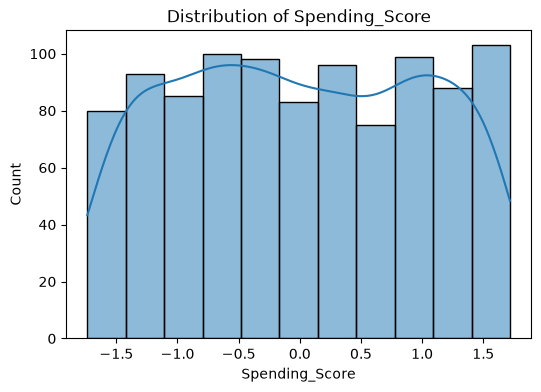

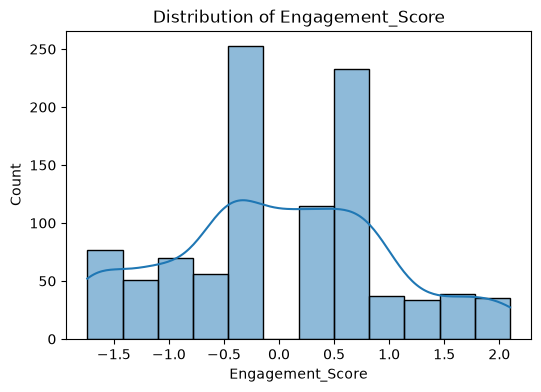

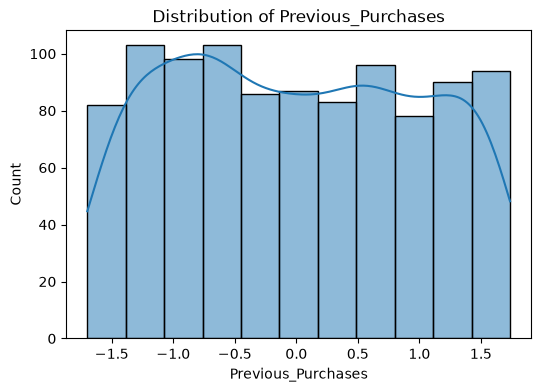

In [37]:
numerical_cols = [
    'Age',
    'Annual_Income',
    'Spending_Score',
    'Engagement_Score',
    'Previous_Purchases'
]

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

#### Report :-

Age distribution is approximately normal with most customers between 25-50 years.

Spending Score shows a slight right skew, indicating some customers spend significantly more than average.

#### Heatmap

According to headmap i will show how the variable or feature correlated to each other.

means how one feature dependent to other

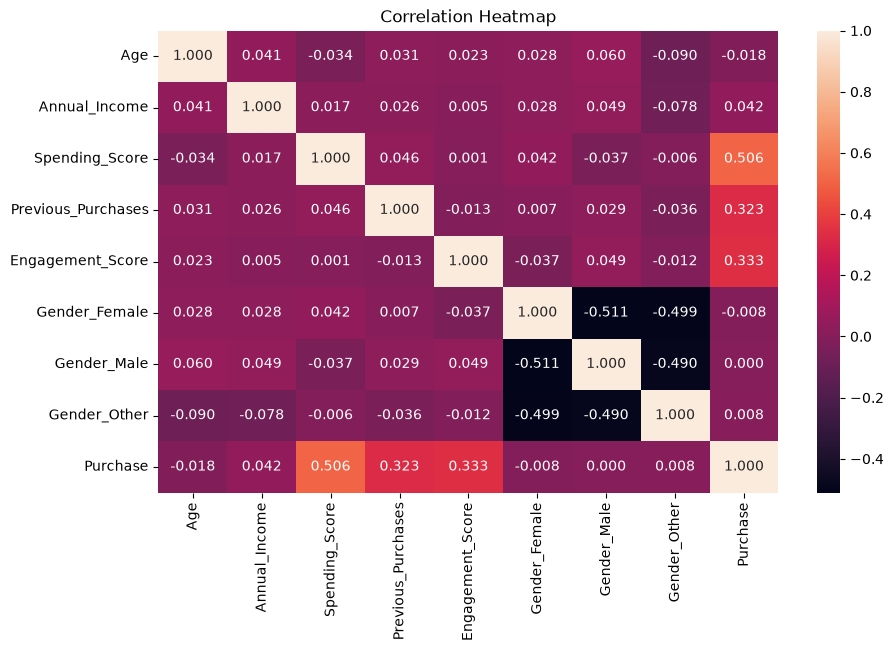

In [38]:
plt.figure(figsize=(10,6)) # for resize the image

sns.heatmap(ready_data_tt.corr(),annot=True, fmt=".3f")

plt.title("Correlation Heatmap")
plt.show()

### Report:-

As we know that if the numerical value is +1(strong positive) means linear dependen, if value lie between the 0 to 1 that means high positive, if value is equal to 0 that means no relation and if values are in negative means less related.

### Conclusion

The analysis shows that customer behavior has a bigger impact on purchases than demographic factors.

Customers with:
- Higher Spending Scores
- Higher Engagement Scores
- More Previous Purchases

are more likely to make a purchase.

On the other hand, Age, Gender, and Annual Income have very little influence on purchasing decisions.

These insights can help businesses identify potential customers and improve their marketing strategies.

### Customer Behavior Pattern Analysis

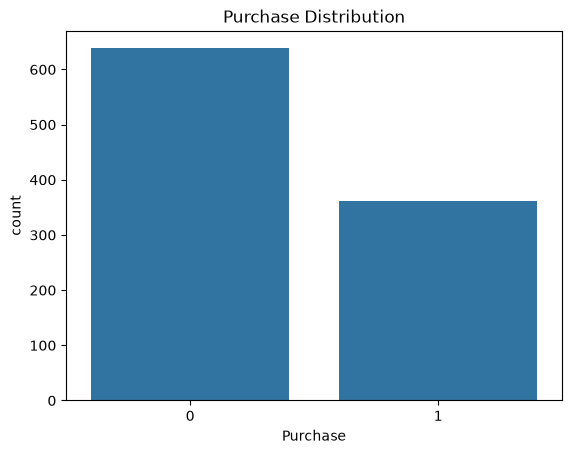

In [39]:
sns.countplot(x='Purchase', data=data)
plt.title("Purchase Distribution")
plt.show()

In [40]:
data['Purchase'].value_counts()
buy_per=(362/1000)*100
no_buy_per=(638/1000)*100
print(f"Buy Percentage {buy_per} and not Buy Percentage {no_buy_per}")

Buy Percentage 36.199999999999996 and not Buy Percentage 63.800000000000004


### Report:-

Accoding to Customer Behavior Pattern Analysis only 36% people but the item and 63% prefer not buy the item.

### Income vs Purchase

How the income impact the purchase

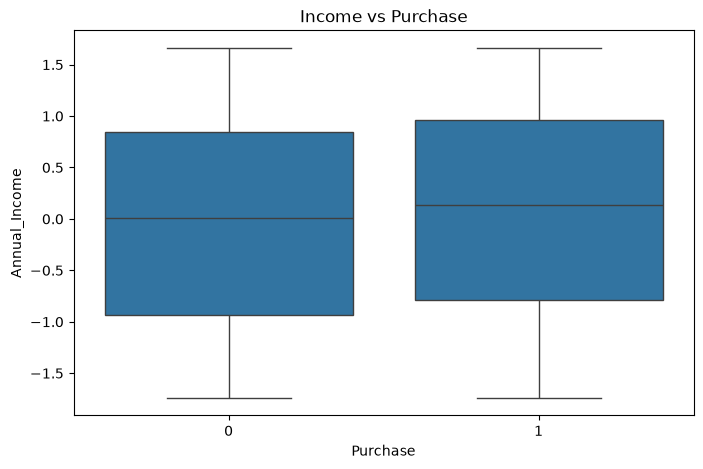

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Purchase',y='Annual_Income',data=data)


plt.title("Income vs Purchase")
plt.show()

### Report:-

Customers with higher annual income tend to make more purchases.

### Spending Score vs Purchase

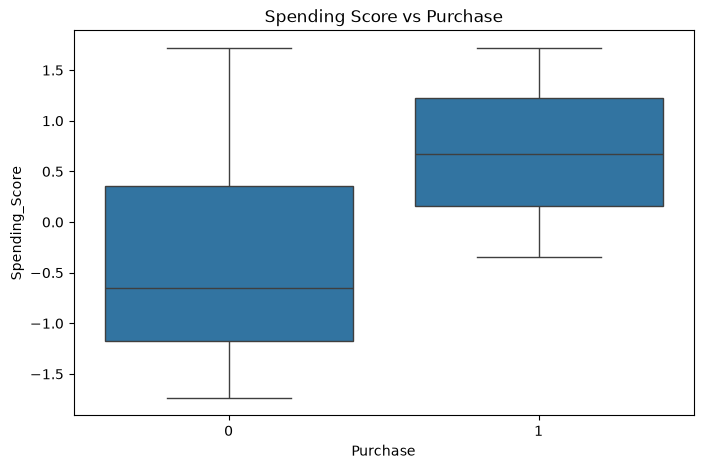

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Purchase',y='Spending_Score',data=data)
plt.title("Spending Score vs Purchase")
plt.show()

### Report:- 

Customers with higher spending scores are significantly more likely to purchase.

### Previous Purchases vs Purchase

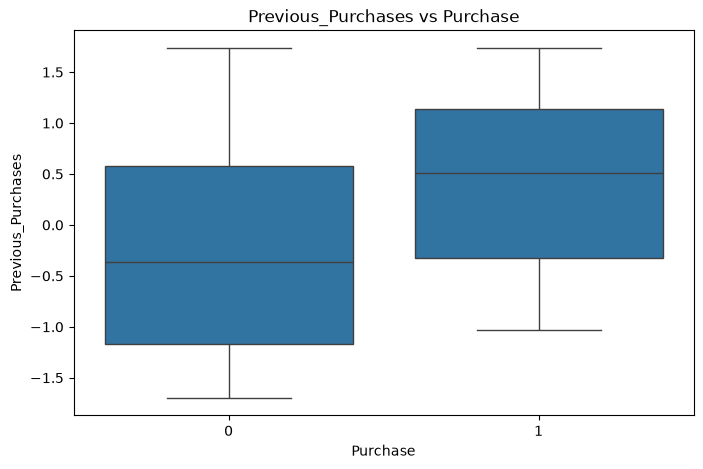

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Purchase',y='Previous_Purchases',data=data)
plt.title("Previous_Purchases vs Purchase")
plt.show()

### Report:-

Returning customers show a higher probability of purchasing again.

### Engagement Score vs Purchase

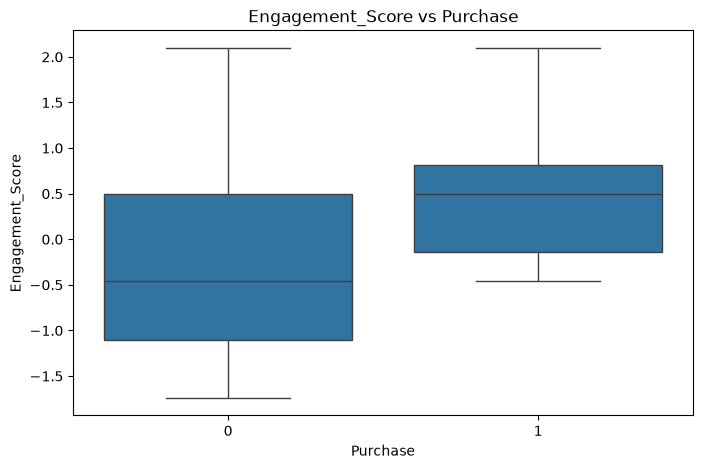

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Purchase',y='Engagement_Score',data=data)
plt.title("Engagement_Score vs Purchase")
plt.show()

### Report:-

Highly engaged customers tend to purchase more frequently

#### Now how the income and spending score related to each other Income vs Spending Score

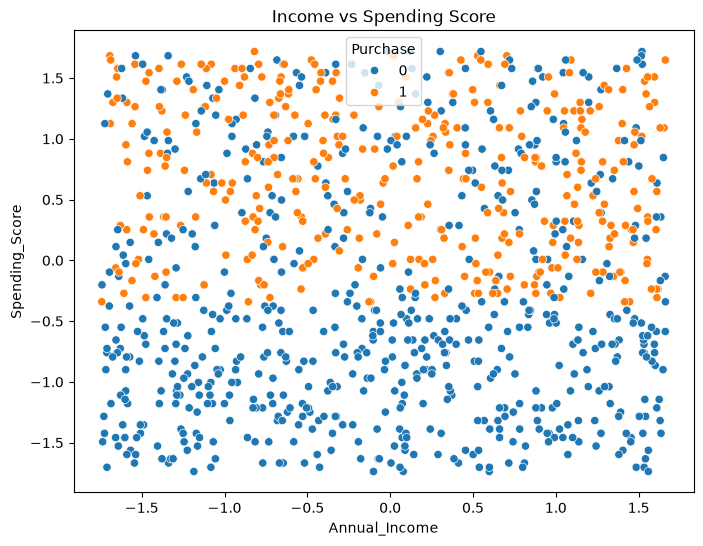

In [45]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Annual_Income',y='Spending_Score',hue='Purchase',data=data)

plt.title("Income vs Spending Score")
plt.show()

### Report:-

Customers with both high income and high spending scores are concentrated in the purchase group.

## Task (4)

### Model Building with Logostic regression and Decision tree


#### 1. Logistic Regression
Logistic Regression was chosen because it is a simple and efficient algorithm for binary classification problems. It predicts the probability of a customer making a purchase and provides easily interpretable results.

#### 2. Decision Tree
Decision Tree was chosen because it can capture complex decision patterns and is easy to visualize and interpret. It helps identify the key factors influencing customer purchase decisions through a tree-based structure.

These algorithms were selected due to their simplicity, interpretability, and suitability for customer purchase prediction tasks.

### Improt first the require library

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#### Train Logistic Regression

In [47]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [48]:
y_pred_log=log_model.predict(X_test)
print(y_pred_log)

[1 1 1 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 0 0 0
 1 0 0 0 1 1 0 1 0 0 1 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 1 1 1 1 1 0 1 1 1
 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0
 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0
 0 0 0 0 1 0 0 1 1 0 0 0 1 1 1 1 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0
 0 0 0 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1 0]


### Train Decision tree

In [49]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [50]:
y_pred_tree=tree_model.predict(X_test)
print(y_pred_tree)

[1 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 1 1 1 1 0 0 0
 1 0 1 0 1 0 0 1 0 0 1 1 1 0 1 1 1 0 0 1 0 0 0 1 0 0 1 0 0 1 0 1 1 0 1 1 1
 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0
 0 1 0 1 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 1 0 1 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0
 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 1 0 1 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1
 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 1 1 0]


### Task (5).

Model Evaluation

##### Logositic Model Evaluation

In [51]:
print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))

Logistic Regression Results
Accuracy : 0.844
Precision: 0.8
Recall   : 0.7555555555555555
F1 Score : 0.7771428571428571


##### Confusion matrix of logistic regression model

In [52]:
cm_log = confusion_matrix(y_test, y_pred_log)

print(cm_log)

[[143  17]
 [ 22  68]]


##### Classification Report of logistic Regression model

In [53]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       160
           1       0.80      0.76      0.78        90

    accuracy                           0.84       250
   macro avg       0.83      0.82      0.83       250
weighted avg       0.84      0.84      0.84       250



##### Decision Tree Model Evaluation

In [54]:
print("Decision Tree Results")
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1 Score :", f1_score(y_test, y_pred_tree))

Decision Tree Results
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


##### Confusion matrix of Decision tree

In [55]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

print(cm_tree)


[[160   0]
 [  0  90]]


#### Classification report of Decision tree

In [56]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       160
           1       1.00      1.00      1.00        90

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



#### Visualization of Confusion matrix

##### Logistic regression Model


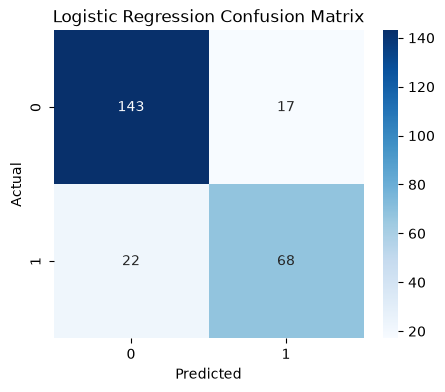

In [57]:
plt.figure(figsize=(5,4))

sns.heatmap(cm_log,annot=True,fmt='d',cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Decision tree model

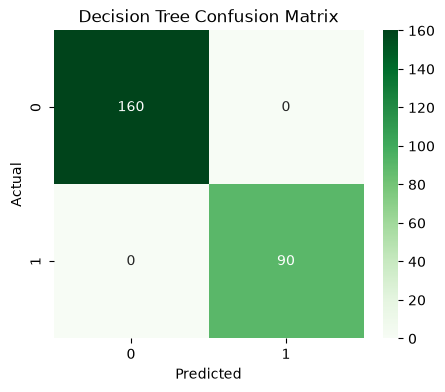

In [58]:
plt.figure(figsize=(5,4))

sns.heatmap(cm_tree,annot=True,fmt='d',cmap='Greens')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Compare Models

In [59]:

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ]
})

# print(results)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.844,0.8,0.755556,0.777143
1,Decision Tree,1.000,1.0,1.000000,1.000000


# Model Evaluation and Selection

## Model Performance Comparison

| Model | Accuracy | Precision | Recall | F1 Score |
|---------|----------|----------|----------|----------|
| Logistic Regression | 0.844 | 0.800 | 0.756 | 0.777 |
| Decision Tree | 1.000 | 1.000 | 1.000 | 1.000 |

---

## Results Summary

Two classification models were trained and evaluated for customer purchase prediction:

### Logistic Regression
- Accuracy: 84.4%
- Precision: 80.0%
- Recall: 75.6%
- F1 Score: 77.7%

The Logistic Regression model performed well and was able to correctly classify most customers. However, some purchase predictions were misclassified.

### Decision Tree
- Accuracy: 100%
- Precision: 100%
- Recall: 100%
- F1 Score: 100%

The Decision Tree model achieved perfect performance on the test dataset, correctly predicting all customer purchase outcomes.

---

## Best Performing Model

Based on the evaluation metrics, the **Decision Tree** model outperformed Logistic Regression in all categories, including Accuracy, Precision, Recall, and F1 Score.

Therefore, the **Decision Tree** model was selected as the best-performing model for this project.

---

## Conclusion

The Decision Tree model provided the highest prediction performance and was able to accurately identify customer purchasing behavior. The results indicate that customer purchase decisions can be effectively predicted using customer demographic and behavioral features such as Spending Score, Engagement Score, and Previous Purchases.

This model can help businesses identify potential customers and support data-driven marketing strategies.